In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import networkExpansionPy.folds as nf
import networkExpansionPy.lib as ne
import glob
import csv
import ast
import json
from scipy.stats import mannwhitneyu
from scipy.stats import spearmanr
from decimal import Decimal

/Users/tseamuscorlett/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/tseamuscorlett/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


In [2]:
# define functions

def todata(dict1, dict2, val_type = 'MEAN'):
    valid_keys = list(dict1.keys() & dict2.keys())
    data1 = [dict1[x] for x in valid_keys]
    data2 = [dict2[x] for x in valid_keys]
    
    if type(data1[0]) == dict:
        data1 = [x[val_type] for x in data1]
        
    if type(data2[0]) == dict:
        data2 = [x[val_type] for x in data2]
    
    return valid_keys, data1, data2

def spearman(dict1, dict2):
    valid_keys, data1, data2 = todata(dict1, dict2)
    correlation, p_value = spearmanr(data1, data2)
    return correlation, p_value

def scatter(dict1, dict2, x_axis = 'x-axis', y_axis = 'y-axis'):
    valid_keys, data1, data2 = todata(dict1, dict2)
    plt.scatter(data1, data2, marker='o', color='b', alpha = 0.1, label='Data Points', zorder=2)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.show()

def loglog(dict1, dict2, x_axis = 'x-axis', y_axis = 'y-axis'):
    valid_keys, data1, data2 = todata(dict1, dict2)
    plt.scatter(np.log10(data1), np.log10(data2), marker='o', color='b', alpha = 0.1, label='Data Points', zorder=2)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.show()

def xlog(dict1, dict2, x_axis = 'x-axis', y_axis = 'y-axis'):
    valid_keys, data1, data2 = todata(dict1, dict2)
    plt.scatter(np.log10(data1), data2, marker='o', color='b', alpha = 0.1, label='Data Points', zorder=2)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.show()

def histogram(dict1, val_type = 'MEAN', bins = 10, x_axis = 'x-axis', y_axis ='counts'):
    data1 = list(dict1.values())
    
    if type(data1[0]) == dict:
        data1 = [x[val_type] for x in data1]
    
    plt.hist(data1, bins=bins, edgecolor='k')
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.show()

def dict2csv(my_dict, csv_file_path):
    with open(csv_file_path, 'w', newline='') as csv_file:
        csv_writer = csv.writer(csv_file)
        for key, value in my_dict.items():
            csv_writer.writerow([key] + [value])

def csv2dict(csv_file_path):
    result_dict = {}
    with open(csv_file_path, 'r') as csv_file:
        csv_reader = csv.reader(csv_file)
        
        for row in csv_reader:
            try:
                result_dict[row[0]] = ast.literal_eval(row[1])  # value is list
            except:
                result_dict[row[0]] = row[1]
                
    return result_dict

# Inspecting the LOO (Leave One Out) network expansion data from fold_results

- number of files in fold_results = **399** (= 397 xgroups + 'independent' and 'spontaneous')

- **node** = cpds (total: **4318**)

- **edge** = reactions = rules (set of folds)


Let's check one file to get what we're looking for

In [3]:
# wo2002 ('without' 2002)
wo2002 = pd.read_pickle('../fold_results_loo/2023-08-21_11-31-01_fold-2002.pkl')

# cpds_cumiter = {'C00036': 0...}  len: 4318   range: 0-89
# cpds_folditer = {'C00036': 0...}  len: 4318   range: 0-2
# cpds_subiter = [{'C00036': 0...}, {'C00311': 0...}, {'C06032': 0...}]  len: 80, 155, 4315; range: 0, 0-4, 0-84

# final_path = None
# iteration = 3

# folds_cumiter = {'2003': 0...}  len: 399; range: 0 or 1 (self = 6)
# folds_folditer = {'2003': 0...}  len: 399; range: 0-2

- **cpds_subiter** is a list with 3 (or 2) dictionaries
- *first dictionary* is always len = **80**<br>
- *second dictionary* has variable lengths = **155-4315**<br>
- *third dictionary* is either len = **4315** or it doesn't exist if len = 4315 in second dictionary<br>

- the second dictionary **cpds_subiter[1]** is what we're looking for<br>

## Create dict 'loo' with all Leave One Out results

In [4]:
folder_path = '../fold_results_loo/'
files_pattern = '*.pkl'
files = glob.glob(folder_path + files_pattern)

loo = {}

# Iterate over each file
for file_path in files:
    # Extract the fold number from the file name
    fold_number = file_path.split('-')[-1].split('.')[0]
    
    # Read the pickle file and populate loo dictionary
    loo[fold_number] = pd.read_pickle(file_path)

In [5]:
first10 = {'206', '2002', '325', '4952', '218', '2005', '2007', '4953', '2003', '602'}
group1 = {'3997', '1', '4011', '253', '7574', '875', '206', '3016', '328', '2486', '212', '148', '2002', '325', '4952', '218', '184', '7577', '2005', '2007', '4953', '7501', '7584', '7579', '297', '2492', '7523', '101', '141', '7544', '109', '2003', '2004', '602', '330', '304', '327'}
group2 = {'7553', '2487', '147', '2011', '4048', '136', '2493', '4004', '217', '210', '911', '3847', '133', '313', '881', '7514', '131', '7550', '603', '4335', '300', '268', '231', '302', '2012', '2006', '323', '7558', '275', '69', '139', '6', '708', '257', '7540', '3740', '331', '7568', '246', '4022', '2484', '3994', '209', '7586', '7549', '6174', '4159', '12', '7589', '3005', '7561', '1114', '4029', '3292', '284', '7500', '3599', '557', '1055', '239', '4018', '2485', '7581', '3156', '3321', '6094', '150', '3294', '7525', '7539', '7513', '3892', '7512', '4', '4971', '230', '5039', '5038', '623', '702', '620', '4093', '3304', '7522', '107', '830', '3447', '5103', '376', '3339', '158', '319', '3264', '102', '3456', '144', '633', '914', '7552', '880', '236', '355', '842', '377', '7517', '4995', '4237', '62', '11', '6166', '221', '298', '3374', '220', '197', '375', '189', '4049', '205', '806', '219', '3993', '3692', '132', '7518', '3688', '813', '7510', '283', '6075', '316', '812', '503', '4279', '315', '228', '4076', '281', '7520', '307', '3685', '324', '374', '1119', '172', '309', '154', '3076', '7509', '4114', '2498', '525', '7542', '207', '7529', '1137', '876', '73', '185', '70', '4052', '4002', '5', '3686', '3579', '650', '129', '3207', '4046', '608', '296', '611', '7516', '243', '7551', '312', '1074', '4178', '222', '5069', '65', '3623', '3001', '3777', '810', '7573', '279', '6096', '4126', '805', '3699', '2500', '276', '3500', '6051', '3858', '5100', '6113', '604', '371', '306', '180', '179', '7595', '7528', '4028', '258', '2', '4019', '1144', '814', '3794', '7588', '66', '75', '108', '528', '1001', '582', '3883', '3371', '7521', '7543', '3086', '920', '285', '3697', '3115', '3323', '241', '4194', '232', '4017', '303', '7531', '5104', '278', '7504', '1143', '244', '6058', '4160', '7546', '378', '2010', '321', '64', '211', '3269', '301', '2008', '7587', '4024', '5084', '7524', '305', '868', '106', '3978', '3322', '4111', '590', '214', '7564', '4044', '10', '3843', '865', '270', '3281', '196', '4161', '213', '7562', '192', '7541', '103', '3691', '7515', '4035', '3052', '3896', '237', '1077', '3960', '7560', '262', '3117', '7604', '7', '4983', '7578', '4229', '4295', '387', '2496', '4045', '4020', '277', '266', '159', '286', '4294', '3009', '4033', '7580', '7601', '5067', '7527', '282', '3018', '7554', '4262', '4272', '7571', '146', '7567', '223', '872', '247', '7507', '601', '314', '9', '7572', '869', '4025', '4036', '235', '581', '3752', '149', '3754', '640', '7602', '199', '208', '4081', '7534', '187', '7556', '3654', '3651', '169', '873', '867', '4021', '3249', '164', '7536', '7563', '629', '632', '4054', '558', '3687', '4110', '177', '3257', '4223'}

# Check if the group1 vs. group2 LOO networks include oxygen or not

In [6]:
# for x in group1:
#     print(f"X{x}: {loo[x].cpds_subiter[1].get('C00007', 'NO OXY')}")

In [7]:
# for x in group2:
#     print(f"X{x}: {loo[x].cpds_subiter[1].get('C00007', 'NO OXY')}")

# Check if the first10 vs. other LOO networks include ATP (NAD+) or not

In [8]:
x2foAveNONE = csv2dict('../data/assets/xgroup2/xgroup2foAveNONE.csv')

In [9]:
first10 = {'206', '2002', '325', '4952', '218', '2005', '2007', '4953', '2003', '602'}
for x in first10:
    print(f"X{x}: foAve={x2foAveNONE[x]}, {loo[x].cpds_subiter[1].get('C00002', 'NO ATP')}")

X2002: foAve=2.0, NO ATP
X218: foAve=11.444, NO ATP
X2007: foAve=12.444, NO ATP
X4952: foAve=106.619, NO ATP
X2005: foAve=79.546, 20
X2003: foAve=6.511, 20
X206: foAve=30.341, NO ATP
X4953: foAve=107.619, NO ATP
X325: foAve=30.293, 20
X602: foAve=106.619, NO ATP


In [10]:
for x in group2 | (group1 - first10):
    print(f"X{x}: {loo[x].cpds_subiter[1].get('C00002', 'NO ATP')}")

X4028: 20
X3692: 20
X3076: 20
X7574: 20
X880: 20
X601: 20
X3892: 20
X7527: 20
X219: 20
X3651: 20
X164: 20
X319: 20
X106: 20
X11: 20
X154: 20
X247: 20
X6113: 20
X7509: 20
X873: 20
X220: 20
X3500: 20
X3322: 20
X1: 20
X3688: 20
X3654: 20
X284: 20
X7512: 20
X172: 20
X3896: 20
X4018: 20
X650: 20
X7514: 20
X1074: 20
X2492: 20
X4004: 20
X611: 20
X205: 20
X4035: 20
X4022: 20
X4995: 20
X1137: 20
X262: 20
X209: 20
X2500: 20
X7531: 20
X865: 20
X69: 20
X3794: 20
X197: 20
X7587: 20
X307: 20
X148: 20
X3016: 20
X7580: 20
X7507: 20
X253: 20
X7513: 20
X558: 20
X867: 20
X3686: 20
X3304: 20
X243: 20
X7521: 20
X3777: 20
X298: 20
X4971: 20
X7561: 20
X3978: 20
X107: 20
X7534: 20
X7529: 20
X5104: 20
X2493: 20
X7517: 20
X1144: 20
X1077: 20
X375: 20
X4126: 20
X4029: 20
X6075: 20
X285: 20
X7558: 20
X374: 20
X257: 20
X7525: 20
X7562: 20
X3117: 20
X300: 20
X282: 20
X4093: 20
X814: 20
X2010: 20
X1055: 20
X376: 20
X296: 20
X3994: 20
X2008: 20
X4002: 20
X2004: 20
X212: 20
X149: 20
X324: 20
X872: 20
X620: 20
X2011: 2

In [11]:
first10 = {'206', '2002', '325', '4952', '218', '2005', '2007', '4953', '2003', '602'}
for x in first10:
    print(f"X{x}: {loo[x].cpds_subiter[1].get('C00004', 'NO NAD')}")

X2002: NO NAD
X218: NO NAD
X2007: NO NAD
X4952: NO NAD
X2005: NO NAD
X2003: 22
X206: NO NAD
X4953: NO NAD
X325: NO NAD
X602: NO NAD


In [12]:
for x in group2 | (group1 - first10):
    print(f"X{x}: {loo[x].cpds_subiter[1].get('C00004', 'NO NAD')}")

X4028: 22
X3692: 22
X3076: 22
X7574: 22
X880: 22
X601: 22
X3892: 22
X7527: 22
X219: 22
X3651: 22
X164: 22
X319: 22
X106: 22
X11: 22
X154: 22
X247: 22
X6113: 22
X7509: 22
X873: 22
X220: 22
X3500: 22
X3322: 22
X1: 22
X3688: 22
X3654: 22
X284: 22
X7512: 22
X172: 22
X3896: 22
X4018: 22
X650: 22
X7514: 22
X1074: 22
X2492: 22
X4004: 22
X611: 22
X205: 22
X4035: 22
X4022: 22
X4995: 22
X1137: 22
X262: 22
X209: 22
X2500: 22
X7531: 22
X865: 22
X69: 22
X3794: 22
X197: 22
X7587: 22
X307: 22
X148: 22
X3016: 22
X7580: 22
X7507: 22
X253: 22
X7513: 22
X558: 22
X867: 22
X3686: 22
X3304: 22
X243: 22
X7521: 22
X3777: 22
X298: 22
X4971: 22
X7561: 22
X3978: 22
X107: 22
X7534: 22
X7529: 22
X5104: 22
X2493: 22
X7517: 22
X1144: 22
X1077: 22
X375: 22
X4126: 22
X4029: 22
X6075: 22
X285: 22
X7558: 22
X374: 22
X257: 22
X7525: 22
X7562: 22
X3117: 22
X300: 22
X282: 22
X4093: 22
X814: 22
X2010: 22
X1055: 22
X376: 22
X296: 22
X3994: 22
X2008: 22
X4002: 22
X2004: 22
X212: 22
X149: 22
X324: 22
X872: 22
X620: 22
X2011: 2

In [13]:
first10 = {'206', '2002', '325', '4952', '218', '2005', '2007', '4953', '2003', '602'}
for x in first10:
    print(f"X{x}: foAve={x2foAveNONE[x]}, {loo[x].cpds_subiter[1].get('C00018', 'NO PLP')}")

X2002: foAve=2.0, NO PLP
X218: foAve=11.444, NO PLP
X2007: foAve=12.444, 7
X4952: foAve=106.619, 7
X2005: foAve=79.546, 7
X2003: foAve=6.511, 7
X206: foAve=30.341, 7
X4953: foAve=107.619, 7
X325: foAve=30.293, 7
X602: foAve=106.619, 7


In [14]:
first10 = {'206', '2002', '325', '4952', '218', '2005', '2007', '4953', '2003', '602'}
for x in first10:
    print(f"X{x}: foAve={x2foAveNONE[x]}, {loo[x].cpds_subiter[1].get('C00010', 'NO CoA')}")

X2002: foAve=2.0, NO CoA
X218: foAve=11.444, NO CoA
X2007: foAve=12.444, NO CoA
X4952: foAve=106.619, NO CoA
X2005: foAve=79.546, NO CoA
X2003: foAve=6.511, NO CoA
X206: foAve=30.341, NO CoA
X4953: foAve=107.619, NO CoA
X325: foAve=30.293, NO CoA
X602: foAve=106.619, NO CoA


In [15]:
first10 = {'206', '2002', '325', '4952', '218', '2005', '2007', '4953', '2003', '602'}
for x in first10:
    print(f"X{x}: foAve={x2foAveNONE[x]}, {loo[x].cpds_subiter[1].get('C00024', 'NO acetyl CoA')}")

X2002: foAve=2.0, NO acetyl CoA
X218: foAve=11.444, NO acetyl CoA
X2007: foAve=12.444, NO acetyl CoA
X4952: foAve=106.619, NO acetyl CoA
X2005: foAve=79.546, NO acetyl CoA
X2003: foAve=6.511, NO acetyl CoA
X206: foAve=30.341, NO acetyl CoA
X4953: foAve=107.619, NO acetyl CoA
X325: foAve=30.293, NO acetyl CoA
X602: foAve=106.619, NO acetyl CoA


In [16]:
first10 = {'206', '2002', '325', '4952', '218', '2005', '2007', '4953', '2003', '602'}
for x in first10:
    print(f"X{x}: foAve={x2foAveNONE[x]}, {loo[x].cpds_subiter[1].get('C00044', 'NO GTP')}")

X2002: foAve=2.0, NO GTP
X218: foAve=11.444, NO GTP
X2007: foAve=12.444, NO GTP
X4952: foAve=106.619, NO GTP
X2005: foAve=79.546, NO GTP
X2003: foAve=6.511, 25
X206: foAve=30.341, NO GTP
X4953: foAve=107.619, NO GTP
X325: foAve=30.293, NO GTP
X602: foAve=106.619, NO GTP


## Collect the network sizes in subiter

In [17]:
# subiter0 = []
# for xgroup in loo:
#     if xgroup != 'spontaneous':
#         subiter0.append(len(loo[xgroup].cpds_subiter[0]))

In [18]:
# subiter1 = []
# for xgroup in loo:
#     if xgroup != 'spontaneous':
#         subiter1.append(len(loo[xgroup].cpds_subiter[1]))

In [19]:
# subiter2 = []
# for xgroup in loo:
#     if xgroup != 'spontaneous':
#         try:
#             subiter2.append(len(loo[xgroup].cpds_subiter[2]))
#         except:
#             subiter2.append(None)

In [20]:
# print(subiter0)

In [21]:
# print(subiter1)

In [22]:
# print(subiter2)

## histogram of network sizes

In [23]:
# # Let's look at the distribution of network sizes

# fig, ax = plt.subplots(1, 1, figsize=(8, 6))
# plt.hist(subiter1, bins = 20)
# ax.axvspan(0, 3600, facecolor='yellow', alpha=0.1)
# ax.axvspan(3600, 4315, facecolor='green', alpha=0.1)
# ax.set_xlabel('scope (network size)')
# ax.set_ylabel('Count')

# # plt.savefig('loo_histogram.png')
# plt.show

In [24]:
# max = list(filter(lambda x: x == 4315, subiter1))
# len(max)

In [25]:
# subiter4300 = list(filter(lambda x: x >= 4300, subiter1))
# len(subiter4300)

In [26]:
# subiter4000 = list(filter(lambda x: x >= 4000, subiter1))
# len(subiter4000)

In [27]:
# # store xgroups as keys

# xgroup2subiter1 = {}
# for xgroup in loo:
#     if xgroup != 'spontaneous':
#         xgroup2subiter1[xgroup] = len(loo[xgroup].cpds_subiter[1])

In [28]:
# dict2csv(xgroup2subiter1, 'xgroup2networkSize.csv')

In [29]:
xgroup2ns = csv2dict('../data/assets/xgroup2/xgroup2networkSize.csv')

## Which xgroups, when left out, leads to smaller network size?

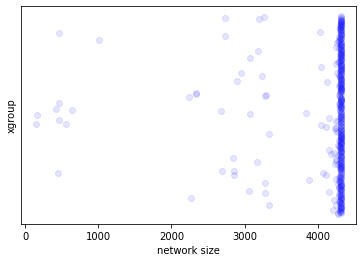

In [30]:
plt.scatter(xgroup2ns.values(), xgroup2ns.keys(), marker='o', color='b', alpha = 0.1, zorder=2)
plt.xlabel('network size')
plt.ylabel('xgroup')
plt.yticks([])
plt.show()

In [31]:
# look at network size < 1500

xgroup2sub1500 = {}
xgroup2sup1500 = {}
for xgroup in xgroup2ns:
    if xgroup2ns[xgroup] < 1500:
        xgroup2sub1500[xgroup] = xgroup2ns[xgroup]
    else:
        xgroup2sup1500[xgroup] = xgroup2ns[xgroup]

In [32]:
# look at network size < 3600

xgroup2sub3600 = {}
xgroup2sup3600 = {}
for xgroup in xgroup2ns:
    if xgroup2ns[xgroup] < 3600:
        xgroup2sub3600[xgroup] = xgroup2ns[xgroup]
    else:
        xgroup2sup3600[xgroup] = xgroup2ns[xgroup]

In [33]:
print(xgroup2sub1500.keys())

dict_keys(['206', '2002', '325', '4952', '218', '2005', '2007', '4953', '2003', '602'])


In [34]:
print(xgroup2sub3600.keys())

dict_keys(['3997', '1', '4011', '253', '7574', '875', '206', '3016', '328', '2486', '212', '148', '2002', '325', '4952', '218', '184', '7577', '2005', '2007', '4953', '7501', '7584', '7579', '297', '2492', '7523', '101', '141', '7544', '109', '2003', '2004', '602', '330', '304', '327'])


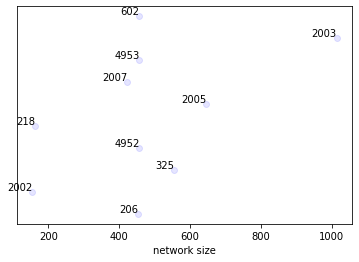

In [35]:
# first10
x = list(xgroup2sub1500.values())
y = list(xgroup2sub1500.keys())

# keys, x, y = todata(xgroup2sub1500, x2rulesNum)

plt.scatter(x, y, marker='o', color='b', alpha = 0.1, zorder=2)
plt.xlabel('network size')
plt.yticks([])
for i, txt in enumerate(y):
    plt.text(x[i], y[i], f'{txt}', ha='right', va='bottom')
plt.show()

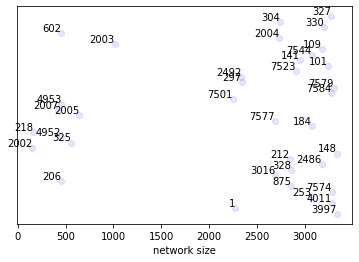

In [36]:
# group1
x = list(xgroup2sub3600.values())
y = list(xgroup2sub3600.keys())

plt.scatter(x, y, marker='o', color='b', alpha = 0.1, zorder=2)
plt.xlabel('network size')
plt.yticks([])
for i, txt in enumerate(y):
    plt.text(x[i], y[i], f'{txt}', ha='right', va='bottom')
plt.show()

## Let's annotate the 'important' xgroups
(using ECOD database and Kolodny et al. Molecular Biology and Evolution, Volume 38, Issue 6, June 2021, Pages 2191–2208, https://doi.org/10.1093/molbev/msab017)

In [37]:
# 206: alpha + beta complex topology
# 218: "Enolase-N/ribosomal protein"
# 325: "alpha/beta-Hammerhead/Barrel-sandwich hybrid"
# 602: "L-aspartase middle domain-like"
# 2002: "TIM beta/alpha-barrel"
# 2003: "Rossmann-like"
# 2005: tRNA_synth related
# 2007: "Flavodoxin-like"
# 4952: no name
# 4953: no name

# rn2rules

In [38]:
rn2rules = pd.read_pickle('../data/assets/rn2rules.20230224.pkl')

In [39]:
print(list(rn2rules.keys()))

['R01015', 'R01061', 'R01063', 'R00200', 'R04779', 'R00658', 'R01070', 'R01786', 'R02740', 'R07159', 'R09084', 'R02189', 'R09085', 'R01512', 'R01518', 'R00431', 'R00726', 'R00341', 'R04780', 'R01827', 'R01641', 'R02739', 'R02736', 'R10907', 'R01056', 'R01830', 'R10221', 'R01529', 'R01528', 'R02035', 'R01049', 'R05605', 'R00709', 'R01900', 'R01325', 'R00268', 'R00267', 'R01324', 'R00351', 'R01899', 'R00472', 'R00342', 'R10612', 'R00473', 'R00479', 'R00705', 'R03045', 'R04432', 'R03158', 'R01608', 'R00706', 'R12356', 'R01383', 'R01896', 'R00286', 'R01476', 'R02640', 'R01481', 'R01639', 'R01478', 'R01904', 'R01381', 'R03313', 'R01251', 'R00239', 'R02291', 'R00480', 'R10147', 'R04475', 'R02734', 'R04199', 'R00451', 'R04365', 'R02735', 'R04198', 'R01773', 'R04405', 'R00946', 'R01286', 'R01775', 'R03260', 'R01777', 'R01466', 'R01771', 'R04173', 'R01513', 'R00582', 'R00586', 'R00897', 'R02412', 'R02413', 'R03460', 'R03083', 'R03084', 'R01826', 'R01714', 'R01373', 'R01715', 'R00694', 'R01728',

In [40]:
print(list(rn2rules.values()))
# set of frozenset(s)...

[{frozenset({'2002'})}, {frozenset({'2003', '298'})}, {frozenset({'2003', '298'})}, {frozenset({'7518', '1'})}, {frozenset({'2007', '7572'})}, {frozenset({'218', '2002'})}, {frozenset({'304'}), frozenset({'2002'})}, {frozenset({'2484'})}, {frozenset({'2007'}), frozenset({'2002'}), frozenset({'10'})}, {frozenset({'169', '806'})}, {frozenset({'2003'})}, {frozenset({'2484'})}, {frozenset({'2003'})}, {frozenset({'7532', '7533'})}, {frozenset({'7554', '7515'}), frozenset({'304', '7515'}), frozenset({'7525'})}, {frozenset({'2004'})}, {frozenset({'2004'})}, {frozenset({'2004'})}, {frozenset({'7587', '4018'}), frozenset({'304'}), frozenset({'246'})}, {frozenset({'2002'})}, {frozenset({'7522', '7574'})}, {frozenset({'2007'}), frozenset({'2002'}), frozenset({'10'})}, {frozenset({'2003', '298'})}, {frozenset({'2003', '298'}), frozenset({'2003'})}, {frozenset({'304', '2003'}), frozenset({'7560'})}, {frozenset({'7522', '7574'})}, {frozenset({'129', '2003'})}, {frozenset({'2002'})}, {frozenset({'129

In [41]:
def numRulesWith(xgroup, rn2rules):
    numRules = 0
    for reaction, rules in rn2rules.items():
        for rule in rules:
            if xgroup in rule:
                numRules += 1
    return numRules

In [42]:
numRulesWith('2003', rn2rules)

3071

In [43]:
len(xgroup2ns.keys())
# 397 + spontaneous

397

In [44]:
x2rulesNum = {}
for xgroup in xgroup2ns.keys():
    x2rulesNum[xgroup] = numRulesWith(xgroup, rn2rules)

In [45]:
list(x2rulesNum.items())

[('7553', 3),
 ('2487', 193),
 ('147', 16),
 ('2011', 118),
 ('4048', 5),
 ('136', 65),
 ('2493', 12),
 ('4004', 16),
 ('217', 204),
 ('210', 90),
 ('911', 2),
 ('3847', 3),
 ('133', 7),
 ('313', 4),
 ('881', 3),
 ('7514', 221),
 ('131', 105),
 ('7550', 44),
 ('3997', 1),
 ('603', 3),
 ('4335', 11),
 ('300', 24),
 ('268', 20),
 ('231', 115),
 ('302', 8),
 ('2012', 30),
 ('2006', 331),
 ('323', 131),
 ('7558', 15),
 ('275', 19),
 ('69', 8),
 ('139', 8),
 ('1', 580),
 ('6', 11),
 ('708', 7),
 ('257', 22),
 ('7540', 3),
 ('3740', 16),
 ('331', 163),
 ('7568', 9),
 ('246', 259),
 ('4011', 144),
 ('4022', 2),
 ('2484', 231),
 ('3994', 1),
 ('209', 18),
 ('253', 1),
 ('7586', 14),
 ('7549', 4),
 ('6174', 4),
 ('4159', 6),
 ('12', 349),
 ('7589', 5),
 ('3005', 18),
 ('7561', 19),
 ('1114', 2),
 ('4029', 8),
 ('3292', 3),
 ('284', 1),
 ('7500', 4),
 ('3599', 2),
 ('7574', 148),
 ('557', 10),
 ('1055', 2),
 ('239', 23),
 ('4018', 31),
 ('2485', 190),
 ('7581', 325),
 ('3156', 44),
 ('3321', 109

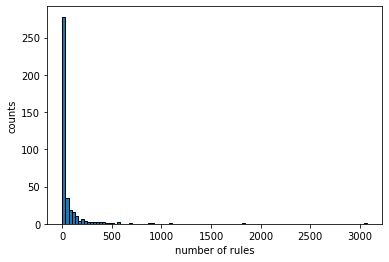

In [46]:
histogram(x2rulesNum, bins=100, x_axis = 'number of rules')

In [47]:
# dict2csv(x2rulesNum, 'xgroup2rulesNum.csv')

# Unique Reactions
A reaction is UNIQUE to that fold if that fold appears in ALL rules associated with the reaction

In [48]:
# R1: {{2002}, {2002, 2}, {2002, 3}}
# then R1 is "unique" to 2002

In [49]:
# fraction
def numUniqueReactionWith(xgroup, rn2rules):
    result = {'unique':[], 'total':[]}
    for reaction, rules in rn2rules.items():
        counter = 0
        for rule in rules:
            for x in rule:
                if x == xgroup:
                    counter += 1              
            if counter == len(rules):
                result['unique'].append(reaction)
                result['total'].append(reaction)
            elif xgroup in rule:
                result['total'].append(reaction)
    return result

In [50]:
x2uniqueTotal = {}
for xgroup in xgroup2ns.keys():
    x2uniqueTotal[xgroup] = numUniqueReactionWith(xgroup, rn2rules)
x2fractionUnique = {}
for xgroup in xgroup2ns.keys():
        x2fractionUnique[xgroup] = len(x2uniqueTotal[xgroup]['unique'])/len(x2uniqueTotal[xgroup]['total'])

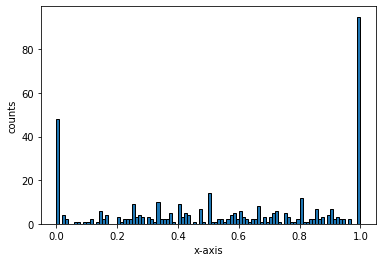

In [51]:
histogram(x2fractionUnique, 'fraction unique', bins=100)

In [52]:
setUniqueX = set()
for x, frac in x2fractionUnique.items():
    if frac > 0.5:  # Unique - threshold? 0.0? 0.5? //// 0.8? (reversed)
        if x != 'spontaneous':
            setUniqueX.add(x)

In [53]:
len(setUniqueX)

223

### class I

In [54]:
len(set(xgroup2sub3600.keys()) & setUniqueX)

29

In [55]:
len(set(xgroup2sub3600.keys()))

37

In [56]:
len(set(xgroup2sub3600.keys()) & setUniqueX) / len(set(xgroup2sub3600.keys()))

0.7837837837837838

### class II

In [57]:
len(set(xgroup2sup3600.keys()) & setUniqueX)

194

In [58]:
len(set(xgroup2sup3600.keys()))

360

In [59]:
len(set(xgroup2sup3600.keys()) & setUniqueX) / len(set(xgroup2sup3600.keys()))

0.5388888888888889

# Independent Rules/Reactions

In [60]:
def numIndepRuleWith(xgroup, rn2rules):
    numRule = 0
    for reaction, rules in rn2rules.items():
        for rule in rules:
            if len(rule) == 1:  # rule contains only one fold => independent
                if xgroup == list(rule)[0]:
                    numRule += 1
    return numRule

In [61]:
ex_dict = {}
ex_dict['a'] = {frozenset({'1'})}  # yes1
ex_dict['b'] = {frozenset({'1'}), frozenset({'2'})}  # yes1, yes2
ex_dict['c'] = {frozenset({'1', '2'})}  # no1, no2
ex_dict['d'] = {frozenset({'1', '2'}), frozenset({'1'})}  # yes1, no2
ex_dict['e'] = {frozenset({'1', '2'}), frozenset({'7'})}  # no1, no2; yes7

print(numIndepRuleWith('1',ex_dict))  # 3
print(numIndepRuleWith('2',ex_dict))  # 1
print(numIndepRuleWith('7',ex_dict))  # 1

3
1
1


In [62]:
numIndepRuleWith('2003', rn2rules)

1284

In [63]:
x2indepRulesNum = {}
for xgroup in xgroup2ns.keys():
    x2indepRulesNum[xgroup] = numIndepRuleWith(xgroup, rn2rules)

In [64]:
x2indepRulesNum

{'7553': 2,
 '2487': 27,
 '147': 0,
 '2011': 54,
 '4048': 0,
 '136': 31,
 '2493': 0,
 '4004': 0,
 '217': 34,
 '210': 51,
 '911': 2,
 '3847': 0,
 '133': 2,
 '313': 0,
 '881': 0,
 '7514': 2,
 '131': 56,
 '7550': 4,
 '3997': 0,
 '603': 0,
 '4335': 0,
 '300': 12,
 '268': 0,
 '231': 4,
 '302': 2,
 '2012': 19,
 '2006': 251,
 '323': 78,
 '7558': 15,
 '275': 0,
 '69': 0,
 '139': 7,
 '1': 61,
 '6': 3,
 '708': 3,
 '257': 10,
 '7540': 0,
 '3740': 6,
 '331': 13,
 '7568': 0,
 '246': 90,
 '4011': 0,
 '4022': 0,
 '2484': 169,
 '3994': 0,
 '209': 2,
 '253': 0,
 '7586': 4,
 '7549': 4,
 '6174': 0,
 '4159': 0,
 '12': 21,
 '7589': 5,
 '3005': 0,
 '7561': 17,
 '1114': 0,
 '4029': 0,
 '3292': 0,
 '284': 0,
 '7500': 0,
 '3599': 0,
 '7574': 9,
 '557': 0,
 '1055': 0,
 '239': 3,
 '4018': 0,
 '2485': 92,
 '7581': 97,
 '3156': 23,
 '3321': 0,
 '6094': 0,
 '150': 42,
 '3294': 0,
 '7525': 68,
 '7539': 4,
 '7513': 6,
 '3892': 0,
 '7512': 387,
 '875': 2,
 '4': 0,
 '4971': 0,
 '230': 26,
 '206': 97,
 '5039': 3,
 '5038

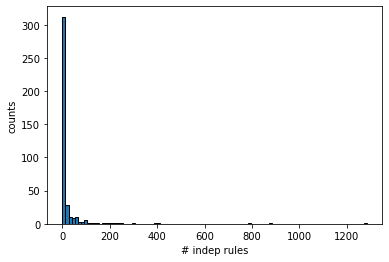

In [65]:
histogram(x2indepRulesNum, x_axis='# indep rules' ,bins=100)

In [66]:
# dict2csv(x2indepRulesNum, 'xgroup2IndepRulesNum.csv')

In [67]:
# fraction

def numIndepRuleWith2(xgroup, rn2rules):
    numRule = 0
    for reaction, rules in rn2rules.items():
        for rule in rules:
            if len(rule) == 1:  # rule contains only one fold => independent
                if xgroup == list(rule)[0]:
                    numRule += 1
    return numRule / numRulesWith(xgroup, rn2rules)

In [68]:
numIndepRuleWith2('2003', rn2rules)

0.4181048518397916

In [69]:
x2indepRulesFraction = {}
for xgroup in xgroup2ns.keys():
    x2indepRulesFraction[xgroup] = numIndepRuleWith2(xgroup, rn2rules)

In [70]:
x2indepRulesFraction

{'7553': 0.6666666666666666,
 '2487': 0.13989637305699482,
 '147': 0.0,
 '2011': 0.4576271186440678,
 '4048': 0.0,
 '136': 0.47692307692307695,
 '2493': 0.0,
 '4004': 0.0,
 '217': 0.16666666666666666,
 '210': 0.5666666666666667,
 '911': 1.0,
 '3847': 0.0,
 '133': 0.2857142857142857,
 '313': 0.0,
 '881': 0.0,
 '7514': 0.00904977375565611,
 '131': 0.5333333333333333,
 '7550': 0.09090909090909091,
 '3997': 0.0,
 '603': 0.0,
 '4335': 0.0,
 '300': 0.5,
 '268': 0.0,
 '231': 0.034782608695652174,
 '302': 0.25,
 '2012': 0.6333333333333333,
 '2006': 0.7583081570996979,
 '323': 0.5954198473282443,
 '7558': 1.0,
 '275': 0.0,
 '69': 0.0,
 '139': 0.875,
 '1': 0.10517241379310345,
 '6': 0.2727272727272727,
 '708': 0.42857142857142855,
 '257': 0.45454545454545453,
 '7540': 0.0,
 '3740': 0.375,
 '331': 0.07975460122699386,
 '7568': 0.0,
 '246': 0.3474903474903475,
 '4011': 0.0,
 '4022': 0.0,
 '2484': 0.7316017316017316,
 '3994': 0.0,
 '209': 0.1111111111111111,
 '253': 0.0,
 '7586': 0.2857142857142857

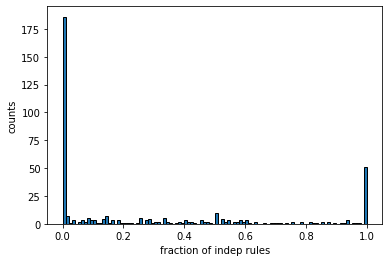

In [71]:
histogram(x2indepRulesFraction, x_axis='fraction of indep rules', bins=100)

In [72]:
# dict2csv(x2indepRulesFraction, 'xgroup2IndepRulesFraction.csv')

## What about fraction of reactions, not rules?

In [73]:
# fraction
def numIndepReactionWith(xgroup, rn2rules):
    result = {'indep':[], 'total':[]}
    for reaction, rules in rn2rules.items():
        for rule in rules:
            if len(rule) == 1:
                if xgroup in rule:
                    result['indep'].append(reaction)
                    result['total'].append(reaction)
            elif xgroup in rule:
                result['total'].append(reaction)
    return result
# returns result = {'indep':[R1, R2], 'total':[R3, R4, R5]}

In [74]:
x2indepTotal = {}
for xgroup in xgroup2ns.keys():
    x2indepTotal[xgroup] = numIndepReactionWith(xgroup, rn2rules)

In [75]:
x2fractionIndep = {}
for xgroup in xgroup2ns.keys():
    x2fractionIndep[xgroup] = len(x2indepTotal[xgroup]['indep'])/len(x2indepTotal[xgroup]['total'])

In [76]:
x2fractionIndep

{'7553': 0.6666666666666666,
 '2487': 0.13989637305699482,
 '147': 0.0,
 '2011': 0.4576271186440678,
 '4048': 0.0,
 '136': 0.47692307692307695,
 '2493': 0.0,
 '4004': 0.0,
 '217': 0.16666666666666666,
 '210': 0.5666666666666667,
 '911': 1.0,
 '3847': 0.0,
 '133': 0.2857142857142857,
 '313': 0.0,
 '881': 0.0,
 '7514': 0.00904977375565611,
 '131': 0.5333333333333333,
 '7550': 0.09090909090909091,
 '3997': 0.0,
 '603': 0.0,
 '4335': 0.0,
 '300': 0.5,
 '268': 0.0,
 '231': 0.034782608695652174,
 '302': 0.25,
 '2012': 0.6333333333333333,
 '2006': 0.7583081570996979,
 '323': 0.5954198473282443,
 '7558': 1.0,
 '275': 0.0,
 '69': 0.0,
 '139': 0.875,
 '1': 0.10517241379310345,
 '6': 0.2727272727272727,
 '708': 0.42857142857142855,
 '257': 0.45454545454545453,
 '7540': 0.0,
 '3740': 0.375,
 '331': 0.07975460122699386,
 '7568': 0.0,
 '246': 0.3474903474903475,
 '4011': 0.0,
 '4022': 0.0,
 '2484': 0.7316017316017316,
 '3994': 0.0,
 '209': 0.1111111111111111,
 '253': 0.0,
 '7586': 0.2857142857142857

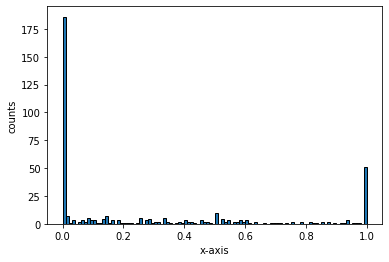

In [77]:
histogram(x2fractionIndep, bins=100)

In [78]:
# dict2csv(x2fractionIndep, 'xgroup2indepRxnFraction.csv')

In [79]:
setIndepX = set()
for x, frac in x2fractionIndep.items():
    if frac > 0:  # independent
        if x != 'spontaneous':
            setIndepX.add(x)

In [80]:
setIndepX

{'1',
 '10',
 '101',
 '107',
 '108',
 '109',
 '11',
 '1119',
 '12',
 '129',
 '131',
 '132',
 '133',
 '136',
 '139',
 '141',
 '146',
 '149',
 '150',
 '158',
 '159',
 '164',
 '172',
 '180',
 '185',
 '2',
 '2002',
 '2003',
 '2004',
 '2005',
 '2006',
 '2007',
 '2010',
 '2011',
 '2012',
 '205',
 '206',
 '207',
 '208',
 '209',
 '210',
 '211',
 '212',
 '213',
 '217',
 '219',
 '220',
 '221',
 '222',
 '223',
 '230',
 '231',
 '232',
 '235',
 '236',
 '237',
 '239',
 '241',
 '243',
 '244',
 '246',
 '247',
 '2484',
 '2485',
 '2486',
 '2487',
 '2492',
 '2498',
 '2500',
 '257',
 '262',
 '266',
 '276',
 '278',
 '281',
 '282',
 '283',
 '285',
 '286',
 '297',
 '298',
 '300',
 '3009',
 '301',
 '3016',
 '302',
 '303',
 '304',
 '305',
 '306',
 '307',
 '3076',
 '3086',
 '309',
 '312',
 '314',
 '315',
 '3156',
 '316',
 '319',
 '3207',
 '321',
 '323',
 '324',
 '3249',
 '325',
 '327',
 '328',
 '330',
 '331',
 '3371',
 '3447',
 '371',
 '374',
 '3740',
 '375',
 '3754',
 '3883',
 '3896',
 '3978',
 '4019',
 '4021'

In [81]:
len(setIndepX)

213

In [82]:
# potential clusters?
set(xgroup2sub3600.keys()) - setIndepX

{'148', '184', '218', '253', '3997', '4011', '4952', '4953', '602', '7544'}

### class I

In [83]:
len(set(xgroup2sub3600.keys()) & setIndepX)

27

In [84]:
len(set(xgroup2sub3600.keys()))

37

In [85]:
len(set(xgroup2sub3600.keys()) & setIndepX) / len(set(xgroup2sub3600.keys()))

0.7297297297297297

### class II

In [86]:
len(set(xgroup2sup3600.keys()) & setIndepX)

186

In [87]:
len(set(xgroup2sup3600.keys()))

360

In [88]:
len(set(xgroup2sup3600.keys()) & setIndepX) / len(set(xgroup2sup3600.keys()))

0.5166666666666667

# Stacked bar chart

In [89]:
# categories =     ['All', 'I', 'II']
# indep_values =     [213, 27, 186]
# not_indep_values = [184, 10, 174]

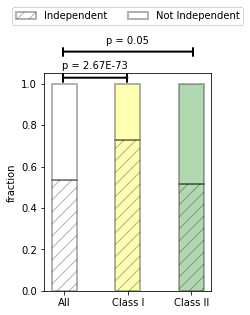

In [90]:
# Data
categories = ['All', 'Class I', 'Class II']
indep_values = [213/397, 27/37, 186/360]
not_indep_values = [184/397, 10/37, 174/360]


# Create a stacked bar chart
bar_width = 0.4
bar_positions = [0, 1, 2]
fig, ax = plt.subplots(figsize=(3, 4))

plt.bar(bar_positions, indep_values, label='Independent', linewidth=2, color=['white', 'yellow', 'green'], edgecolor=(0, 0, 0, 1), alpha = 0.3, hatch='//',  width=bar_width)
plt.bar(bar_positions, not_indep_values, bottom=indep_values, label='Not Independent', linewidth=2, color=['white', 'yellow', 'green'], edgecolor=(0, 0, 0, 1), alpha = 0.3,  width=bar_width)

# Set labels
plt.xticks(bar_positions, categories)
plt.ylabel('fraction')
ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.2), ncol=2)

# chi-square: 2.66954E-73 (1 vs. all); 0.05 (2 vs. all)
ax.annotate('p = 2.67E-73', xy=(0.305, 1.035), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')
ax.annotate('p = 0.05', xy=(0.500, 1.15), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')

# brackets
ax.annotate('', xy=(0.1, 0.98), xytext=(0.51, 0.98), xycoords='axes fraction',
           textcoords='axes fraction', arrowprops=dict(arrowstyle='|-|, widthA=0.4, widthB=0.4, angleA=0, angleB=0', lw=2, color='k'))
ax.annotate('', xy=(0.1, 1.1), xytext=(0.9, 1.1), xycoords='axes fraction',
            textcoords='axes fraction', arrowprops=dict(arrowstyle='|-|, widthA=0.4, widthB=0.4, angleA=0, angleB=0', lw=2, color='k'))


# Show the plot
# plt.savefig('indepFraction_bar.png', bbox_inches='tight')

plt.show()


0.7493246794572518


/var/folders/y2/h8jnq3ld4ng6lrxsflrh300c0000gp/T/ipykernel_2662/1089910998.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([class1ds, class2ds], labels=['Class I', 'Class II'], patch_artist=True, positions=[1, 1.5])


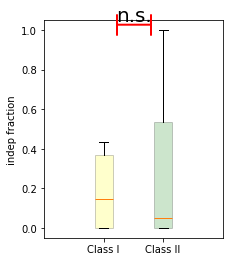

In [91]:
keys, data1, data2 = todata(x2fractionIndep, xgroup2sub1500)  # 10
keys, data3, data4 = todata(x2fractionIndep, xgroup2sup1500)  # 387
class1ds = np.array(data1)
class2ds = np.array(data3)

fig, ax = plt.subplots(figsize=(3.2, 4))
bp = ax.boxplot([class1ds, class2ds], labels=['Class I', 'Class II'], patch_artist=True, positions=[1, 1.5])
colors = ['yellow', 'green']
for box, color in zip(bp['boxes'], colors):
    box.set(facecolor=color, edgecolor='black', alpha = 0.2)

# significance bracket
statistic, p_value = mannwhitneyu(class1ds, class2ds)
print(p_value)
if p_value < 0.001:
    significance_text = '***'
elif p_value < 0.01:
    significance_text = '**'
elif p_value < 0.05:
    significance_text = '*'
else:
    significance_text = 'n.s.'
ax.annotate(significance_text, xy=(0.505, 1.02), xycoords='axes fraction', ha='center', va='center', fontsize=20, color='black')
ax.annotate('', xy=(0.61, 0.98), xytext=(0.40, 0.98), xycoords='axes fraction',
            textcoords='axes fraction', arrowprops=dict(arrowstyle='|-|, widthA=1, widthB=1, angleA=0, angleB=0', lw=2, color='red'))


plt.ylabel('indep fraction')
# plt.savefig('boxplot_ds.png', bbox_inches='tight')
plt.show()

In [92]:
x2indepRulesFraction['602']

0.0

In [93]:
x2indepRulesFraction['4952']

0.0

In [94]:
x2indepRulesFraction['4953']

0.0

In [95]:
x2indepRulesFraction['2003']

0.4181048518397916

In [96]:
x2indepRulesFraction['2002']

0.4342607746863066

In [97]:
x2indepRulesFraction['2005']

0.3984375

# Boxplots

In [98]:
ab_path = '../data/assets/xgroup2/DS_average/xgroup2DS_average_ArcBac_recovered.csv'
xgroup2ds_ab = csv2dict(ab_path)
print(len(xgroup2ds_ab))

# class I
print(len(xgroup2sub1500))

# class II
print(len(xgroup2sup1500))

2230
10
387


## Boxplot - distribution score

7.441191216364195e-14


/var/folders/y2/h8jnq3ld4ng6lrxsflrh300c0000gp/T/ipykernel_2662/505619990.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([class1ds, class2ds], labels=['Class I', 'Class II'], patch_artist=True, positions=[1, 1.5])


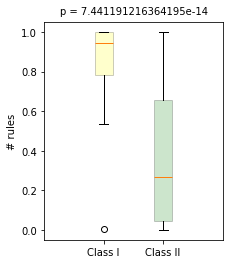

In [99]:
keys, data1, data2 = todata(xgroup2ds_ab, xgroup2sub3600) 
keys, data3, data4 = todata(xgroup2ds_ab, xgroup2sup3600)  
class1ds = np.array(data1)
class2ds = np.array(data3)

fig, ax = plt.subplots(figsize=(3.2, 4))
bp = ax.boxplot([class1ds, class2ds], labels=['Class I', 'Class II'], patch_artist=True, positions=[1, 1.5])
colors = ['yellow', 'green']
for box, color in zip(bp['boxes'], colors):
    box.set(facecolor=color, edgecolor='black', alpha = 0.2)
    
# sns.stripplot(data=[class1ds, class2ds], color='black', size=2, jitter=True, ax=ax)

# significance bracket
statistic, p_value = mannwhitneyu(class1ds, class2ds)
print(p_value)
ax.annotate(f'p = {p_value}', xy=(0.505, 1.05), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')
# ax.annotate('', xy=(0.61, 0.98), xytext=(0.40, 0.98), xycoords='axes fraction',
#            textcoords='axes fraction', arrowprops=dict(arrowstyle='|-|, widthA=0.5, widthB=0.5, angleA=0, angleB=0', lw=2, color='red'))


plt.ylabel('# rules')
# plt.savefig('boxplot_numRules.png', bbox_inches='tight')
plt.show()

/var/folders/y2/h8jnq3ld4ng6lrxsflrh300c0000gp/T/ipykernel_2662/1024275070.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Group I', 'Group II'], fontsize=11)


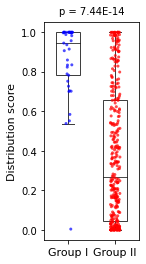

In [100]:
keys, data1, data2 = todata(xgroup2ds_ab, xgroup2sub3600) 
keys, data3, data4 = todata(xgroup2ds_ab, xgroup2sup3600)

group1ds = np.array(data1)
group2ds = np.array(data3)

fig, ax = plt.subplots(figsize=(1.7, 4))

# Use seaborn boxplot
boxplot = sns.boxplot(data=[group1ds, group2ds], width=0.5, ax=ax, medianprops=dict(color="black", alpha=0.7),
            flierprops=dict(markerfacecolor="#FFFFFF", marker=""))

# Adjust alpha for the boxes
for patch in boxplot.patches:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0))

# data points
colors = ['blue', 'red']
sns.stripplot(data=[group1ds, group2ds], palette=colors, size=3, jitter=True, ax=ax, alpha=0.7)

###
# U-test
statistic, p_value = mannwhitneyu(group1ds, group2ds)
p_value = '%.2E' % Decimal(p_value)
ax.annotate(f'p = {p_value}', xy=(0.505, 1.05), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')
###

plt.tick_params(labelsize=10)
plt.ylabel('Distribution score', fontsize=11)
ax.set_xticklabels(['Group I', 'Group II'], fontsize=11)

# plt.savefig('boxplot_ds_g1g2.svg', dpi=300, bbox_inches = 'tight')
plt.show()

/var/folders/y2/h8jnq3ld4ng6lrxsflrh300c0000gp/T/ipykernel_2662/125267438.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Group I', 'Group II'], fontsize=11)


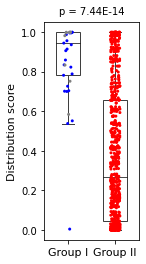

In [101]:
keys, data5, data6 = todata(xgroup2ds_ab, xgroup2sub1500)
first10ds = np.array(data5)

group1minus10 = set(data1) - set(data5)
group1minus10ds = np.array(list(group1minus10))

fig, ax = plt.subplots(figsize=(1.7, 4))

# Use seaborn boxplot
boxplot = sns.boxplot(data=[group1ds, group2ds], width=0.5, ax=ax, medianprops=dict(color="black", alpha=0.7),
            flierprops=dict(markerfacecolor="#FFFFFF", marker=""))

# Adjust alpha for the boxes
for patch in boxplot.patches:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0))

# data points
colors = ['blue', 'red']
sns.stripplot(data=[group1minus10ds, group2ds], palette=colors, size=3, jitter=True, ax=ax, alpha=1)
colors = ['gray', 'red']
sns.stripplot(data=[first10ds, group2ds], palette=colors, size=3, jitter=True, ax=ax, alpha=1)

###
# U-test
statistic, p_value = mannwhitneyu(group1ds, group2ds)
p_value = '%.2E' % Decimal(p_value)
ax.annotate(f'p = {p_value}', xy=(0.505, 1.05), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')
###

plt.tick_params(labelsize=10)
plt.ylabel('Distribution score', fontsize=11)
ax.set_xticklabels(['Group I', 'Group II'], fontsize=11)

# plt.savefig('boxplot_ds_g1g2_first10.svg', dpi=300, bbox_inches = 'tight')
plt.show()

## bottom outlier in boxplot Class I

In [102]:
for x in xgroup2sub3600.keys():
    print(x, xgroup2ds_ab[x], xgroup2sub3600[x])

3997 0.004198171025249323 3332.0
1 1.0000003589638293 2268.0
4011 0.7017233158969953 3277.0
253 0.538151559161858 3063.0
7574 0.9570208608635665 3282.0
875 0.5517578444971232 2855.0
206 0.9998620544745564 454.0
3016 0.9882885382966389 2687.0
328 0.9963546054588688 2853.0
2486 0.8235156924410404 3173.0
212 0.9999991683884243 2841.0
148 0.999954309210021 3329.0
2002 1.0000003589638293 155.0
325 0.996845996683019 555.0
4952 0.7522045253668491 457.0
218 0.9824581938682911 163.0
184 0.7269055853818388 3069.0
7577 0.9969062075563079 2684.0
2005 1.0000003589638293 645.0
2007 1.0000003589638293 423.0
4953 0.5843828224868748 457.0
7501 0.7041318317370185 2247.0
7584 0.70040898698321 3275.0
7579 0.8350103649801142 3299.0
297 0.9067096475060743 2339.0
2492 0.9450544816624569 2337.0
7523 0.859495201106993 2901.0
101 1.0000003589638293 3240.0
141 0.9148272583837381 2951.0
7544 0.7823048519427597 3069.0
109 0.936863662298508 3180.0
2003 1.0000003589638293 1014.0
2004 1.0000003589638293 2731.0
602 0.

In [103]:
print(xgroup2ns['3997'])  # ns = 3332
print(x2rulesNum['3997'])  # rulesNum = 1

3332.0
1


In [104]:
# x2rxn['3997']
# >> ['R03877']

In [105]:
rn2rules['R03877']  # {frozenset({'109', '148', '2004', '2007', '3997'})}

{frozenset({'109', '148', '2004', '2007', '3997'})}

In [106]:
# first committed step of chlorophyll biosynthesis
# and is a branchpoint of two major routes in the tetrapyrrole pathway.

In [107]:
# X3997 is the LAST class I fold, with ns = 3332 (highest in Class I)

In [108]:
# print(f"{xgroup2ds_a['3997']}, {xgroup2ds_b['3997']}, {xgroup2ds_e['3997']}")
# 0.001515541650790627, 0.00688080039970802, 0.25

## Boxplot - # rules

In [109]:
rule_path = '../data/assets/xgroup2/xgroup2rulesNum.csv'
xgroup2numRules = csv2dict(rule_path)
print(len(xgroup2numRules))

397


1.2868510217906621e-08


/var/folders/y2/h8jnq3ld4ng6lrxsflrh300c0000gp/T/ipykernel_2662/2323359347.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([class1ds, class2ds], labels=['Class I', 'Class II'], patch_artist=True, positions=[1, 1.5])


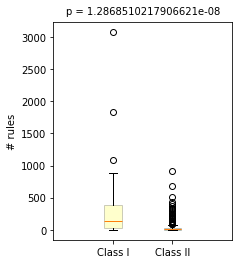

In [110]:
keys, data1, data2 = todata(xgroup2numRules, xgroup2sub3600) 
keys, data3, data4 = todata(xgroup2numRules, xgroup2sup3600)  
class1ds = np.array(data1)
class2ds = np.array(data3)

fig, ax = plt.subplots(figsize=(3.2, 4))
bp = ax.boxplot([class1ds, class2ds], labels=['Class I', 'Class II'], patch_artist=True, positions=[1, 1.5])
colors = ['yellow', 'green']
for box, color in zip(bp['boxes'], colors):
    box.set(facecolor=color, edgecolor='black', alpha = 0.2)

# significance bracket
statistic, p_value = mannwhitneyu(class1ds, class2ds)
print(p_value)
ax.annotate(f'p = {p_value}', xy=(0.505, 1.05), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')
# ax.annotate('', xy=(0.61, 0.98), xytext=(0.40, 0.98), xycoords='axes fraction',
#            textcoords='axes fraction', arrowprops=dict(arrowstyle='|-|, widthA=0.5, widthB=0.5, angleA=0, angleB=0', lw=2, color='red'))


plt.ylabel('# rules')
# plt.savefig('boxplot_numRules.png', bbox_inches='tight')
plt.show()

## Boxplot - repetitiveness

In [111]:
rep_path = '../data/assets/xgroup2/xgroup2repetitiveness_v1.json'
with open(rep_path, 'r') as file:
    xgroup2rep = json.load(file)
print(len(xgroup2rep))

379


/var/folders/y2/h8jnq3ld4ng6lrxsflrh300c0000gp/T/ipykernel_2662/661449564.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([class1ds, class2ds], labels=['Class I', 'Class II'], patch_artist=True, positions=[1, 1.5])


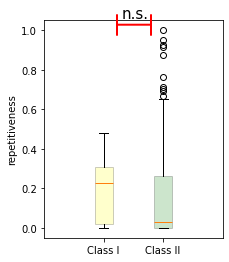

In [112]:
keys, data1, data2 = todata(xgroup2rep, xgroup2sub1500)  # 10
keys, data3, data4 = todata(xgroup2rep, xgroup2sup1500)  # 387
class1ds = np.array(data1)
class2ds = np.array(data3)

fig, ax = plt.subplots(figsize=(3.2, 4))
bp = ax.boxplot([class1ds, class2ds], labels=['Class I', 'Class II'], patch_artist=True, positions=[1, 1.5])
colors = ['yellow', 'green']
for box, color in zip(bp['boxes'], colors):
    box.set(facecolor=color, edgecolor='black', alpha = 0.2)

# significance bracket
statistic, p_value = mannwhitneyu(class1ds, class2ds)
if p_value < 0.001:
    significance_text = '***'
elif p_value < 0.01:
    significance_text = '**'
elif p_value < 0.05:
    significance_text = '*'
else:
    significance_text = 'n.s.'
ax.annotate(significance_text, xy=(0.51, 1.03), xycoords='axes fraction', ha='center', va='center', fontsize=15, color='black')
ax.annotate('', xy=(0.61, 0.98), xytext=(0.40, 0.98), xycoords='axes fraction',
            textcoords='axes fraction', arrowprops=dict(arrowstyle='|-|, widthA=1, widthB=1, angleA=0, angleB=0', lw=2, color='red'))


plt.ylabel('repetitiveness')
# plt.savefig('boxplot_repetitiveness.png', bbox_inches='tight')
plt.show()

# network size vs. #rules

In [113]:
morethan4000 = []
for x in xgroup2ns.keys():
    if xgroup2ns[x] > 4000:
        morethan4000.append(x)
print(len(morethan4000))  # 358 without spontaneous

358


network size vs. #rules: corr = -0.6035693134562072, p_value = 9.196312874064563e-41


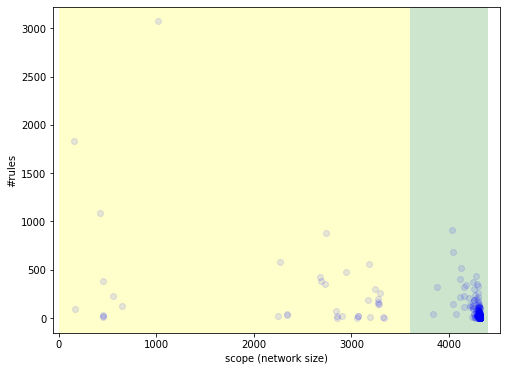

In [114]:
corr, p = spearman(xgroup2ns, x2rulesNum)
print(f'network size vs. #rules: corr = {corr}, p_value = {p}')

valid_keys, data1, data2 = todata(xgroup2ns, x2rulesNum)
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
plt.scatter(data1, data2, marker='o', color='b', alpha = 0.1, label='Data Points', zorder=2)
ax.axvspan(0, 3600, facecolor='yellow', alpha=0.2)
ax.axvspan(3600, 4400, facecolor='green', alpha=0.2)
ax.set_xlabel('scope (network size)')
ax.set_ylabel('#rules')

# plt.savefig('scatter_networkSize2numRules.png')
plt.show()

network size vs. #rules: corr = -0.6035693134562072, p_value = 9.196312874064563e-41


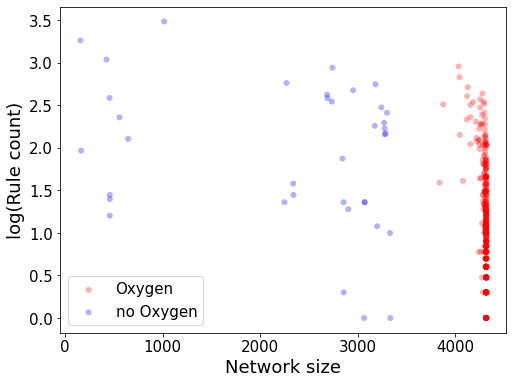

In [115]:
# annotate the presence/absence of Oxygen in the network

corr, p = spearman(xgroup2ns, x2rulesNum)
print(f'network size vs. #rules: corr = {corr}, p_value = {p}')

valid_keys, data1, data2 = todata(xgroup2sup3600, x2rulesNum)
valid_keys, data3, data4 = todata(xgroup2sub3600, x2rulesNum)
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

plt.scatter(data1, np.log10(data2), marker='o', edgecolor='none', color='r', alpha = 0.3, label='Data Points', zorder=2)
plt.scatter(data3, np.log10(data4), marker='o', edgecolor='none', color='b', alpha = 0.3, label='Data Points', zorder=2, )

# ax.axvspan(0, 3600, facecolor='yellow', alpha=0.2)
# ax.axvspan(3600, 4400, facecolor='green', alpha=0.2)
ax.set_xlabel('Network size', fontsize=18)
ax.set_ylabel('log(Rule count)', fontsize=18)
plt.tick_params(labelsize=15)
ax.legend(loc='lower left', labels=['Oxygen', 'no Oxygen'], fontsize=15)

# plt.savefig('scatter_networkSize2numRulesLog.svg', dpi=300, bbox_inches = 'tight')
plt.show()

In [116]:
print('X, scope, #rules')
print('----------------')
for key, value in xgroup2sub1500.items():
    print(key, value, x2rulesNum[key])

X, scope, #rules
----------------
206 454.0 387
2002 155.0 1833
325 555.0 229
4952 457.0 25
218 163.0 93
2005 645.0 128
2007 423.0 1093
4953 457.0 16
2003 1014.0 3071
602 457.0 28


# Co-dependence analysis

In [117]:
import itertools

In [118]:
# example

ex_dict = {}
ex_dict['a'] = {frozenset({'1', '2'})}  # ok
ex_dict['b'] = {frozenset({'1', '2'}), frozenset({'7'})}  # ok
ex_dict['c'] = {frozenset({'1', '2', '3'})}  # ok
ex_dict['d'] = {frozenset({'1'}), frozenset({'2'})}  # no
ex_dict['e'] = {frozenset({'1', '2'}), frozenset({'1'})}  # no 

In [119]:
combo = ['1', '2']

# original version where ex_dict['c'] was 'no'
# for reaction, rules in ex_dict.items():
#     contains_12 = frozenset(combo) in rules
#     contains_1 = frozenset(combo[0]) in rules
#     contains_2 = frozenset(combo[1]) in rules

#     if contains_12 and not contains_1 and not contains_2:
#         print(f"{reaction}: ok")
#     else:
#         print(f"{reaction}: no")

# new, relaxed version
for reaction, rules in ex_dict.items():
    
    contains_12 = frozenset(combo) in rules
    contains_1 = frozenset(combo[0]) in rules
    contains_2 = frozenset(combo[1]) in rules

    if contains_12 and not contains_1 and not contains_2:
        print(f"{reaction}: ok")
    elif any(set(combo).issubset(rule) for rule in rules) and not contains_1 and not contains_2:
        print(f"{reaction}: ok2")
    else:
        print(f"{reaction}: no")

a: ok
b: ok
c: ok2
d: no
e: no


In [120]:
# 10C2

combo2rn = {}
for combo in itertools.combinations(xgroup2sub1500.keys(), 2):
    rn = []
    # iterate through rn2rules
    for reaction, rules in rn2rules.items():
        contains_12 = frozenset(combo) in rules
        contains_1 = frozenset(combo[0]) in rules
        contains_2 = frozenset(combo[1]) in rules

        #original
        # if contains_12 and not contains_1 and not contains_2:
            # rn.append(reaction)
        
        # new
        if contains_12 and not contains_1 and not contains_2:
            rn.append(reaction)
        elif any(set(combo).issubset(rule) for rule in rules) and not contains_1 and not contains_2:
            rn.append(reaction)
    combo2rn[combo] = rn

In [121]:
combo2rn

{('206', '2002'): ['R00206',
  'R00344',
  'R00575',
  'R01397',
  'R01993',
  'R03295',
  'R01557',
  'R00256',
  'R01395',
  'R02108',
  'R02112',
  'R10948',
  'R10949',
  'R11262',
  'R06218',
  'R06209',
  'R07641',
  'R08201',
  'R00256_v2',
  'R01395_v2',
  'R07641_v1',
  'R00344_v2',
  'R10948_v2',
  'R00575_v1',
  'R11262_v1',
  'R00344_v1',
  'R08201_v1',
  'R01993_v1',
  'R00344_v3',
  'R00256_v1',
  'R10949_v1',
  'R10949_v2',
  'R08201_v2',
  'R03295_v1',
  'R02108_v1',
  'R02112_v1',
  'R10948_v1',
  'R00206_v1',
  'R01395_v1',
  'R07641_v2',
  'R00575_v2',
  'R01993_v2'],
 ('206', '325'): ['R07404',
  'R00344',
  'R00742',
  'R01859',
  'R04138',
  'R04144',
  'R04208',
  'R04209',
  'R04325',
  'R04591',
  'R06974',
  'R00005',
  'R00774',
  'R03494',
  'R04326',
  'R04385',
  'R04386',
  'R08924',
  'R08201',
  'R01859_v1',
  'R00344_v2',
  'R04144_v1',
  'R04208_gATP',
  'R03494_v1',
  'R04385_v1',
  'R00344_v1',
  'R08201_v1',
  'R06974_gATP',
  'R04591_v1',
  'R0034

In [122]:
combo2rnNum = {}
for key, values in combo2rn.items():
    combo2rnNum[key] = len(values)

In [123]:
combo2rnNum

{('206', '2002'): 42,
 ('206', '325'): 38,
 ('206', '4952'): 0,
 ('206', '218'): 0,
 ('206', '2005'): 18,
 ('206', '2007'): 56,
 ('206', '4953'): 0,
 ('206', '2003'): 130,
 ('206', '602'): 0,
 ('2002', '325'): 17,
 ('2002', '4952'): 0,
 ('2002', '218'): 93,
 ('2002', '2005'): 3,
 ('2002', '2007'): 157,
 ('2002', '4953'): 0,
 ('2002', '2003'): 118,
 ('2002', '602'): 0,
 ('325', '4952'): 0,
 ('325', '218'): 0,
 ('325', '2005'): 0,
 ('325', '2007'): 1,
 ('325', '4953'): 0,
 ('325', '2003'): 43,
 ('325', '602'): 0,
 ('4952', '218'): 0,
 ('4952', '2005'): 0,
 ('4952', '2007'): 0,
 ('4952', '4953'): 13,
 ('4952', '2003'): 0,
 ('4952', '602'): 23,
 ('218', '2005'): 0,
 ('218', '2007'): 0,
 ('218', '4953'): 0,
 ('218', '2003'): 0,
 ('218', '602'): 0,
 ('2005', '2007'): 21,
 ('2005', '4953'): 0,
 ('2005', '2003'): 20,
 ('2005', '602'): 0,
 ('2007', '4953'): 0,
 ('2007', '2003'): 145,
 ('2007', '602'): 0,
 ('4953', '2003'): 0,
 ('4953', '602'): 15,
 ('2003', '602'): 0}

In [124]:
print(combo2rnNum[('4952', '602')])
print(combo2rnNum[('4952', '4953')])
print(combo2rnNum[('4953', '602')])

23
13
15


In [125]:
# combo2rnNum[('602', '4952')] KeyError
# combo2rnNum[('602', '4953')] KeyError
# combo2rnNum[('4953', '4952')] KeyError

In [126]:
print(combo2rn[('4953', '602')])
print(combo2rn[('4952', '602')])

['R00259', 'R01086', 'R00697', 'R00737', 'R01083', 'R04559', 'R01082', 'R00490', 'R10286', 'R06132', 'R10286_v1', 'R00697_v1', 'R00737_v1', 'R01082_v1', 'R06132_v1']
['R00697', 'R00737', 'R01168', 'R01083', 'R11366', 'R11391', 'R04559', 'R01082', 'R11432', 'R00490', 'R03307', 'R11749', 'R00739', 'R10286', 'R06132', 'R10286_v1', 'R00697_v1', 'R11366_v1', 'R00739_v1', 'R00737_v1', 'R01082_v1', 'R06132_v1', 'R01168_v1']


In [127]:
print(rn2rules['R01086'])

{frozenset({'4953', '213', '602'}), frozenset({'4953', '602'})}


In [128]:
for reaction in combo2rn[('4952', '602')]:
    print(rn2rules[reaction])

{frozenset({'4953', '4952', '602'})}
{frozenset({'4953', '4952', '602'})}
{frozenset({'4952', '602'})}
{frozenset({'4953', '4952', '602'})}
{frozenset({'4952', '602'})}
{frozenset({'4952', '602'})}
{frozenset({'4953', '4952', '602'})}
{frozenset({'4953', '4952', '602'}), frozenset({'2487', '2485'})}
{frozenset({'4952', '602'})}
{frozenset({'4953', '4952', '602'})}
{frozenset({'4952', '602'})}
{frozenset({'4952', '602'})}
{frozenset({'4952', '602'})}
{frozenset({'4953', '4952', '602'})}
{frozenset({'4953', '4952', '602'}), frozenset({'2002', '7521'}), frozenset({'2003'}), frozenset({'4952', '602'})}
{frozenset({'4953', '4952', '602'})}
{frozenset({'4953', '4952', '602'})}
{frozenset({'4952', '602'})}
{frozenset({'4952', '602'})}
{frozenset({'4953', '4952', '602'})}
{frozenset({'4953', '4952', '602'}), frozenset({'2487', '2485'})}
{frozenset({'4953', '4952', '602'}), frozenset({'2002', '7521'}), frozenset({'2003'}), frozenset({'4952', '602'})}
{frozenset({'4952', '602'})}


## Draw a network

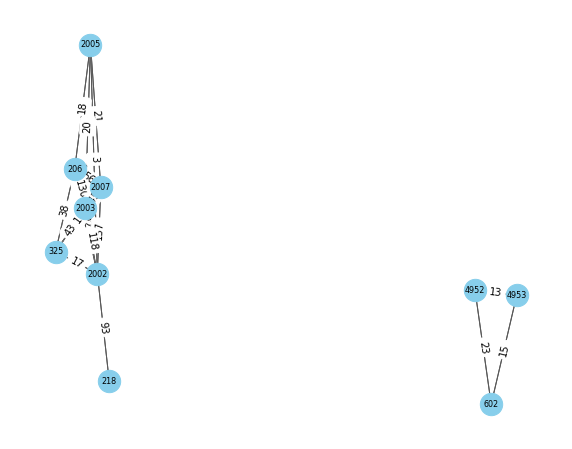

In [129]:
import networkx as nx
import matplotlib.pyplot as plt

# Your data
data = combo2rnNum

# Create a graph
G = nx.Graph()

# Add edges with weights
for (source, target), weight in data.items():
    if weight != 0:
        G.add_edge(source, target, weight=weight)

# Draw the graph
fig, ax = plt.subplots(figsize=(10, 8))  # Adjust the figure size
pos = nx.spring_layout(G, scale=1000)  # You can use other layouts as well
labels = nx.get_edge_attributes(G, 'weight')

# Set alpha based on weight (invisible if weight is zero)
edge_alphas = [(source, target, 0.7 if weight != 0 else 0) for (source, target, weight) in G.edges(data='weight')]

nx.draw(G, pos, with_labels=True, node_size=500, node_color="skyblue", font_size=8, ax=ax)
nx.draw_networkx_edges(G, pos, edgelist=edge_alphas, alpha=0.7, edge_color='gray')  # Draw edges with alpha

nx.draw_networkx_edge_labels(G, pos, edge_labels=labels, ax=ax)

# plt.savefig('codep_network.png')
plt.show()

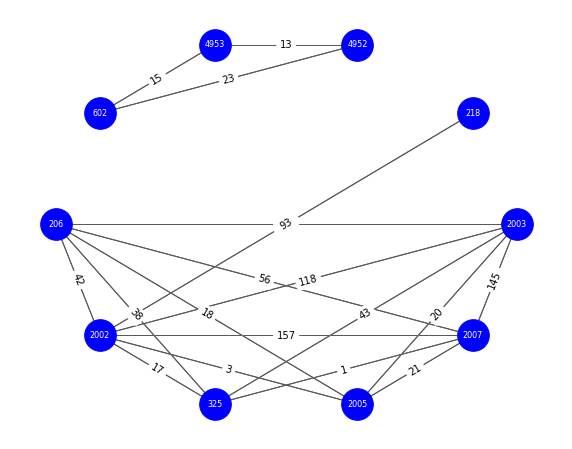

In [130]:
# Your data
data = combo2rnNum

# Create a graph
G = nx.Graph()


# Add edges with weights
for (source, target), weight in data.items():
    if weight != 0:
        G.add_edge(source, target, weight=weight)

# Draw the graph
fig, ax = plt.subplots(figsize=(10, 8))
pos = nx.shell_layout(G)  # Use shell_layout
labels = nx.get_edge_attributes(G, 'weight')

# Set alpha based on weight (invisible if weight is zero)
edge_alphas = [(source, target, 0.7 if weight != 0 else 0) for (source, target, weight) in G.edges(data='weight')]

nx.draw(G, pos, with_labels=True, node_size=1000, node_color="blue", font_size=8, ax=ax, font_color = 'white')
nx.draw_networkx_edges(G, pos, edgelist=edge_alphas, alpha=0.7, edge_color='gray')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels, ax=ax)

# plt.savefig('codep_network_shell.png')
plt.show()

In [131]:
# trio

trio = frozenset({'602', '4952', '4953'})
    # iterate through rn2rules
for reaction, rules in rn2rules.items():
    if trio in rules:
        print(reaction, rules)

# 13 rules exist with {'602', '4952', '4953'}, where 9 have no other rules

R00697 {frozenset({'4953', '4952', '602'})}
R00737 {frozenset({'4953', '4952', '602'})}
R01083 {frozenset({'4953', '4952', '602'})}
R04559 {frozenset({'4953', '4952', '602'})}
R01082 {frozenset({'4953', '4952', '602'}), frozenset({'2487', '2485'})}
R00490 {frozenset({'4953', '4952', '602'})}
R10286 {frozenset({'4953', '4952', '602'})}
R06132 {frozenset({'4953', '4952', '602'}), frozenset({'2002', '7521'}), frozenset({'2003'}), frozenset({'4952', '602'})}
R10286_v1 {frozenset({'4953', '4952', '602'})}
R00697_v1 {frozenset({'4953', '4952', '602'})}
R00737_v1 {frozenset({'4953', '4952', '602'})}
R01082_v1 {frozenset({'4953', '4952', '602'}), frozenset({'2487', '2485'})}
R06132_v1 {frozenset({'4953', '4952', '602'}), frozenset({'2002', '7521'}), frozenset({'2003'}), frozenset({'4952', '602'})}


## combo, but allow solo rule

In [132]:
# 10C2

comboLoose2rn = {}
for combo in itertools.combinations(xgroup2sub1500.keys(), 2):
    rn = []
    # iterate through rn2rules
    for reaction, rules in rn2rules.items():
        contains_12 = frozenset(combo) in rules

        if contains_12:
            rn.append(reaction)
    comboLoose2rn[combo] = rn

In [133]:
comboLoose2rn

{('206', '2002'): ['R03295', 'R03295_v1'],
 ('206', '325'): [],
 ('206', '4952'): [],
 ('206', '218'): [],
 ('206', '2005'): [],
 ('206', '2007'): ['R04209', 'R04591', 'R04591_v1', 'R04591_gATP_v1'],
 ('206', '4953'): [],
 ('206', '2003'): ['R09775',
  'R03429',
  'R10929',
  'R11064',
  'R10902',
  'R06975',
  'R00497',
  'R03479',
  'R09401',
  'R01150',
  'R09588',
  'R03428',
  'R10994',
  'R09595',
  'R11085',
  'R06975_gATP_v1',
  'R01150_v1',
  'R10902_v6',
  'R11085_v2',
  'R00497_v2',
  'R10902_v3',
  'R03428_v1',
  'R10902_v1',
  'R00497_v1',
  'R09775_v1',
  'R11085_v1',
  'R10994_v1',
  'R10902_v2',
  'R03479_v1',
  'R10994_v2',
  'R06975_v1',
  'R11064_v1',
  'R10902_v5',
  'R10902_v4',
  'R09588_v1',
  'R09401_v1',
  'R11064_v2',
  'R03429_v1'],
 ('206', '602'): [],
 ('2002', '325'): ['R03348', 'R01271'],
 ('2002', '4952'): [],
 ('2002', '218'): ['R00658',
  'R05606',
  'R04031',
  'R01538',
  'R03033',
  'R06989',
  'R10532',
  'R03696',
  'R05392',
  'R09229',
  'R09135

In [134]:
comboLoose2rnNum = {}
for key, values in combo2rn.items():
    comboLoose2rnNum[key] = len(values)

In [135]:
comboLoose2rnNum

{('206', '2002'): 42,
 ('206', '325'): 38,
 ('206', '4952'): 0,
 ('206', '218'): 0,
 ('206', '2005'): 18,
 ('206', '2007'): 56,
 ('206', '4953'): 0,
 ('206', '2003'): 130,
 ('206', '602'): 0,
 ('2002', '325'): 17,
 ('2002', '4952'): 0,
 ('2002', '218'): 93,
 ('2002', '2005'): 3,
 ('2002', '2007'): 157,
 ('2002', '4953'): 0,
 ('2002', '2003'): 118,
 ('2002', '602'): 0,
 ('325', '4952'): 0,
 ('325', '218'): 0,
 ('325', '2005'): 0,
 ('325', '2007'): 1,
 ('325', '4953'): 0,
 ('325', '2003'): 43,
 ('325', '602'): 0,
 ('4952', '218'): 0,
 ('4952', '2005'): 0,
 ('4952', '2007'): 0,
 ('4952', '4953'): 13,
 ('4952', '2003'): 0,
 ('4952', '602'): 23,
 ('218', '2005'): 0,
 ('218', '2007'): 0,
 ('218', '4953'): 0,
 ('218', '2003'): 0,
 ('218', '602'): 0,
 ('2005', '2007'): 21,
 ('2005', '4953'): 0,
 ('2005', '2003'): 20,
 ('2005', '602'): 0,
 ('2007', '4953'): 0,
 ('2007', '2003'): 145,
 ('2007', '602'): 0,
 ('4953', '2003'): 0,
 ('4953', '602'): 15,
 ('2003', '602'): 0}

In [136]:
print(comboLoose2rnNum[('4952', '602')])
print(comboLoose2rnNum[('4952', '4953')])
print(comboLoose2rnNum[('4953', '602')])

23
13
15


In [137]:
# doesn't increase rnNum! these folds are definitely co-dep

# look for more trouples

In [138]:
troupleMaybe = set(xgroup2sub3600.keys()) - setIndepX
troupleMaybe

{'148', '184', '218', '253', '3997', '4011', '4952', '4953', '602', '7544'}

In [139]:
# same as above, but with the new set

comboMaybe2rn = {}
for combo in itertools.combinations(troupleMaybe, 2):
    rn = []
    # iterate through rn2rules
    for reaction, rules in rn2rules.items():
        contains_12 = frozenset(combo) in rules
        contains_1 = frozenset(combo[0]) in rules
        contains_2 = frozenset(combo[1]) in rules

        #original
        # if contains_12 and not contains_1 and not contains_2:
            # rn.append(reaction)
        
        # new
        if contains_12 and not contains_1 and not contains_2:
            rn.append(reaction)
        elif any(set(combo).issubset(rule) for rule in rules) and not contains_1 and not contains_2:
            rn.append(reaction)
    comboMaybe2rn[combo] = rn

In [140]:
comboMaybe2rn

{('218', '4011'): [],
 ('218', '253'): [],
 ('218', '7544'): [],
 ('218', '184'): [],
 ('218', '4952'): [],
 ('218', '4953'): [],
 ('218', '3997'): [],
 ('218', '148'): [],
 ('218', '602'): [],
 ('4011', '253'): [],
 ('4011', '7544'): [],
 ('4011', '184'): [],
 ('4011', '4952'): [],
 ('4011', '4953'): [],
 ('4011', '3997'): [],
 ('4011', '148'): [],
 ('4011', '602'): [],
 ('253', '7544'): [],
 ('253', '184'): [],
 ('253', '4952'): [],
 ('253', '4953'): [],
 ('253', '3997'): [],
 ('253', '148'): [],
 ('253', '602'): [],
 ('7544', '184'): ['R00985',
  'R00986',
  'R01073',
  'R08222',
  'R10836',
  'R10837',
  'R10838',
  'R08230',
  'R01570',
  'R01876',
  'R02296',
  'R02484',
  'R02298',
  'R00985_v1',
  'R02296_v1',
  'R01073_v1',
  'R02484_v1',
  'R01570_v1',
  'R02298_v1',
  'R00986_v1',
  'R01876_v1'],
 ('7544', '4952'): [],
 ('7544', '4953'): [],
 ('7544', '3997'): [],
 ('7544', '148'): [],
 ('7544', '602'): [],
 ('184', '4952'): [],
 ('184', '4953'): [],
 ('184', '3997'): [],
 (

In [141]:
comboMaybe2rnNum = {}
for key, values in comboMaybe2rn.items():
    comboMaybe2rnNum[key] = len(values)

In [142]:
comboMaybe2rnNum

{('218', '4011'): 0,
 ('218', '253'): 0,
 ('218', '7544'): 0,
 ('218', '184'): 0,
 ('218', '4952'): 0,
 ('218', '4953'): 0,
 ('218', '3997'): 0,
 ('218', '148'): 0,
 ('218', '602'): 0,
 ('4011', '253'): 0,
 ('4011', '7544'): 0,
 ('4011', '184'): 0,
 ('4011', '4952'): 0,
 ('4011', '4953'): 0,
 ('4011', '3997'): 0,
 ('4011', '148'): 0,
 ('4011', '602'): 0,
 ('253', '7544'): 0,
 ('253', '184'): 0,
 ('253', '4952'): 0,
 ('253', '4953'): 0,
 ('253', '3997'): 0,
 ('253', '148'): 0,
 ('253', '602'): 0,
 ('7544', '184'): 21,
 ('7544', '4952'): 0,
 ('7544', '4953'): 0,
 ('7544', '3997'): 0,
 ('7544', '148'): 0,
 ('7544', '602'): 0,
 ('184', '4952'): 0,
 ('184', '4953'): 0,
 ('184', '3997'): 0,
 ('184', '148'): 0,
 ('184', '602'): 0,
 ('4952', '4953'): 13,
 ('4952', '3997'): 0,
 ('4952', '148'): 0,
 ('4952', '602'): 23,
 ('4953', '3997'): 0,
 ('4953', '148'): 0,
 ('4953', '602'): 15,
 ('3997', '148'): 1,
 ('3997', '602'): 0,
 ('148', '602'): 0}

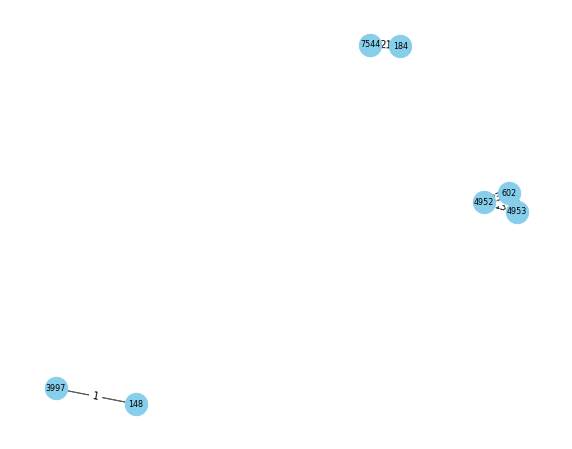

In [143]:
# Your data
data = comboMaybe2rnNum

# Create a graph
G = nx.Graph()

# Add edges with weights
for (source, target), weight in data.items():
    if weight != 0:
        G.add_edge(source, target, weight=weight)

# Draw the graph
fig, ax = plt.subplots(figsize=(10, 8))  # Adjust the figure size
pos = nx.spring_layout(G, scale=1000)  # You can use other layouts as well
labels = nx.get_edge_attributes(G, 'weight')

# Set alpha based on weight (invisible if weight is zero)
edge_alphas = [(source, target, 0.7 if weight != 0 else 0) for (source, target, weight) in G.edges(data='weight')]

nx.draw(G, pos, with_labels=True, node_size=500, node_color="skyblue", font_size=8, ax=ax)
nx.draw_networkx_edges(G, pos, edgelist=edge_alphas, alpha=0.7, edge_color='gray')  # Draw edges with alpha

nx.draw_networkx_edge_labels(G, pos, edge_labels=labels, ax=ax)

# plt.savefig('codep_network.png')
plt.show()

# Unique reactions

In [144]:
def numRnWith(xgroup, rn2rules):
    numRn = 0
    for reaction, rules in rn2rules.items():
        for rule in rules:
            if xgroup in rule:
                numRn += 1
                break
    return numRn

In [145]:
x2RnNum = {}
for xgroup in xgroup2ns.keys():
    x2RnNum[xgroup] = numRnWith(xgroup, rn2rules)

In [146]:
x2RnNum['2003']

2673

In [147]:
print(x2RnNum['602'], x2RnNum['4952'], x2RnNum['4953'])  # 25 23 15

25 23 15


In [148]:
for reaction, rules in rn2rules.items():
    for rule in rules:
        if '4953' in rule:
            print(reaction, rules)
            break

R00259 {frozenset({'7531', '213'}), frozenset({'4953', '213', '602'}), frozenset({'3117', '231'}), frozenset({'213'})}
R01086 {frozenset({'4953', '213', '602'}), frozenset({'4953', '602'})}
R00697 {frozenset({'4953', '4952', '602'})}
R00737 {frozenset({'4953', '4952', '602'})}
R01083 {frozenset({'4953', '4952', '602'})}
R04559 {frozenset({'4953', '4952', '602'})}
R01082 {frozenset({'4953', '4952', '602'}), frozenset({'2487', '2485'})}
R00490 {frozenset({'4953', '4952', '602'})}
R10286 {frozenset({'4953', '4952', '602'})}
R06132 {frozenset({'4953', '4952', '602'}), frozenset({'2002', '7521'}), frozenset({'2003'}), frozenset({'4952', '602'})}
R10286_v1 {frozenset({'4953', '4952', '602'})}
R00697_v1 {frozenset({'4953', '4952', '602'})}
R00737_v1 {frozenset({'4953', '4952', '602'})}
R01082_v1 {frozenset({'4953', '4952', '602'}), frozenset({'2487', '2485'})}
R06132_v1 {frozenset({'4953', '4952', '602'}), frozenset({'2002', '7521'}), frozenset({'2003'}), frozenset({'4952', '602'})}


In [149]:
for reaction, rules in rn2rules.items():
    for rule in rules:
        if '4952' in rule:
            print(reaction, rules)
            break

R00697 {frozenset({'4953', '4952', '602'})}
R00737 {frozenset({'4953', '4952', '602'})}
R01168 {frozenset({'4952', '602'})}
R01083 {frozenset({'4953', '4952', '602'})}
R11366 {frozenset({'4952', '602'})}
R11391 {frozenset({'4952', '602'})}
R04559 {frozenset({'4953', '4952', '602'})}
R01082 {frozenset({'4953', '4952', '602'}), frozenset({'2487', '2485'})}
R11432 {frozenset({'4952', '602'})}
R00490 {frozenset({'4953', '4952', '602'})}
R03307 {frozenset({'4952', '602'})}
R11749 {frozenset({'4952', '602'})}
R00739 {frozenset({'4952', '602'})}
R10286 {frozenset({'4953', '4952', '602'})}
R06132 {frozenset({'4953', '4952', '602'}), frozenset({'2002', '7521'}), frozenset({'2003'}), frozenset({'4952', '602'})}
R10286_v1 {frozenset({'4953', '4952', '602'})}
R00697_v1 {frozenset({'4953', '4952', '602'})}
R11366_v1 {frozenset({'4952', '602'})}
R00739_v1 {frozenset({'4952', '602'})}
R00737_v1 {frozenset({'4953', '4952', '602'})}
R01082_v1 {frozenset({'4953', '4952', '602'}), frozenset({'2487', '248

In [150]:
for reaction, rules in rn2rules.items():
    for rule in rules:
        if '602' in rule:
            print(reaction, rules)
            break

R00259 {frozenset({'7531', '213'}), frozenset({'4953', '213', '602'}), frozenset({'3117', '231'}), frozenset({'213'})}
R01086 {frozenset({'4953', '213', '602'}), frozenset({'4953', '602'})}
R00697 {frozenset({'4953', '4952', '602'})}
R00737 {frozenset({'4953', '4952', '602'})}
R01168 {frozenset({'4952', '602'})}
R01083 {frozenset({'4953', '4952', '602'})}
R11366 {frozenset({'4952', '602'})}
R11391 {frozenset({'4952', '602'})}
R04559 {frozenset({'4953', '4952', '602'})}
R01082 {frozenset({'4953', '4952', '602'}), frozenset({'2487', '2485'})}
R11432 {frozenset({'4952', '602'})}
R00490 {frozenset({'4953', '4952', '602'})}
R03307 {frozenset({'4952', '602'})}
R11749 {frozenset({'4952', '602'})}
R00739 {frozenset({'4952', '602'})}
R10286 {frozenset({'4953', '4952', '602'})}
R06132 {frozenset({'4953', '4952', '602'}), frozenset({'2002', '7521'}), frozenset({'2003'}), frozenset({'4952', '602'})}
R10286_v1 {frozenset({'4953', '4952', '602'})}
R00697_v1 {frozenset({'4953', '4952', '602'})}
R1136

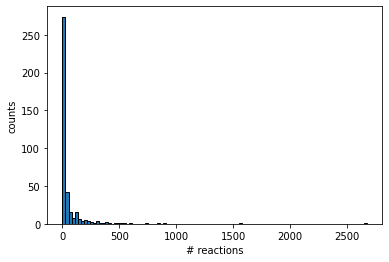

In [151]:
histogram(x2RnNum, x_axis = '# reactions', bins=100)

In [152]:
# R: {{2002}, {2002, 2}, {2002, 3}}
# then this reaction is "unique" to 2002

In [153]:
def numUniqueRnWith(xgroup, rn2rules):
    numRn = 0
    for reaction, rules in rn2rules.items():
        counter = 0
        for rule in rules:
            for x in rule:
                if x == xgroup:
                    counter += 1
                    
        if counter == len(rules):
            numRn += 1
    return numRn

In [154]:
x2uniqueRnNum = {}
for xgroup in xgroup2ns.keys():
    x2uniqueRnNum[xgroup] = numUniqueRnWith(xgroup, rn2rules)

In [155]:
x2uniqueRnNum

{'7553': 3,
 '2487': 114,
 '147': 14,
 '2011': 71,
 '4048': 1,
 '136': 50,
 '2493': 6,
 '4004': 14,
 '217': 182,
 '210': 44,
 '911': 2,
 '3847': 0,
 '133': 1,
 '313': 4,
 '881': 0,
 '7514': 147,
 '131': 21,
 '7550': 16,
 '3997': 1,
 '603': 3,
 '4335': 3,
 '300': 14,
 '268': 17,
 '231': 98,
 '302': 6,
 '2012': 24,
 '2006': 123,
 '323': 118,
 '7558': 9,
 '275': 4,
 '69': 0,
 '139': 7,
 '1': 381,
 '6': 10,
 '708': 1,
 '257': 22,
 '7540': 3,
 '3740': 16,
 '331': 141,
 '7568': 0,
 '246': 75,
 '4011': 133,
 '4022': 2,
 '2484': 162,
 '3994': 1,
 '209': 5,
 '253': 1,
 '7586': 8,
 '7549': 4,
 '6174': 4,
 '4159': 6,
 '12': 128,
 '7589': 5,
 '3005': 10,
 '7561': 19,
 '1114': 0,
 '4029': 3,
 '3292': 0,
 '284': 1,
 '7500': 0,
 '3599': 2,
 '7574': 126,
 '557': 4,
 '1055': 2,
 '239': 11,
 '4018': 20,
 '2485': 95,
 '7581': 139,
 '3156': 19,
 '3321': 4,
 '6094': 33,
 '150': 95,
 '3294': 1,
 '7525': 21,
 '7539': 4,
 '7513': 6,
 '3892': 0,
 '7512': 383,
 '875': 2,
 '4': 27,
 '4971': 8,
 '230': 21,
 '206'

In [156]:
x2uniqueRnNum['2002']

1162

In [157]:
# dict2csv(x2uniqueRnNum, 'xgroup2uniqueRnNum.csv')

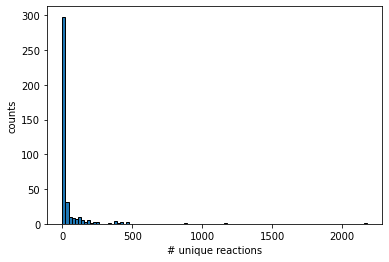

In [158]:
histogram(x2uniqueRnNum, x_axis = '# unique reactions', bins=100)

In [159]:
# divide each y-value (unique) with total #reactions catalyzed by that fold

def numUniqueRnWith2(xgroup, rn2rules):
    numRn = 0
    for reaction, rules in rn2rules.items():
        counter = 0
        for rule in rules:
            for x in rule:
                if x == xgroup:
                    counter += 1
                    
        if counter == len(rules):
            numRn += 1
    return numRn / numRnWith(xgroup, rn2rules)

In [160]:
x2uniqueRnNum2 = {}
for xgroup in xgroup2ns.keys():
    x2uniqueRnNum2[xgroup] = numUniqueRnWith2(xgroup, rn2rules)

In [161]:
x2uniqueRnNum2

{'7553': 1.0,
 '2487': 0.8201438848920863,
 '147': 0.875,
 '2011': 0.696078431372549,
 '4048': 0.2,
 '136': 0.7692307692307693,
 '2493': 0.6,
 '4004': 0.875,
 '217': 0.900990099009901,
 '210': 0.6567164179104478,
 '911': 1.0,
 '3847': 0.0,
 '133': 0.16666666666666666,
 '313': 1.0,
 '881': 0.0,
 '7514': 0.7577319587628866,
 '131': 0.3,
 '7550': 0.64,
 '3997': 1.0,
 '603': 1.0,
 '4335': 0.2727272727272727,
 '300': 0.9333333333333333,
 '268': 0.85,
 '231': 0.8672566371681416,
 '302': 0.75,
 '2012': 1.0,
 '2006': 0.411371237458194,
 '323': 0.9291338582677166,
 '7558': 0.6,
 '275': 0.25,
 '69': 0.0,
 '139': 0.875,
 '1': 0.774390243902439,
 '6': 0.9090909090909091,
 '708': 0.16666666666666666,
 '257': 1.0,
 '7540': 1.0,
 '3740': 1.0,
 '331': 0.8980891719745223,
 '7568': 0.0,
 '246': 0.36231884057971014,
 '4011': 0.9568345323741008,
 '4022': 1.0,
 '2484': 0.7431192660550459,
 '3994': 1.0,
 '209': 0.2777777777777778,
 '253': 1.0,
 '7586': 0.6666666666666666,
 '7549': 1.0,
 '6174': 1.0,
 '4159'

In [162]:
# dict2csv(x2uniqueRnNum2, 'xgroup2uniqueRnFraction.csv')

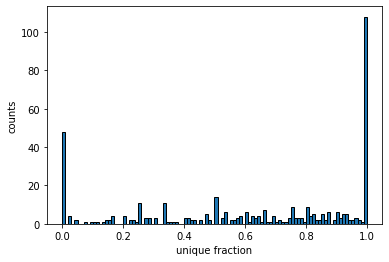

In [163]:
histogram(x2uniqueRnNum2, x_axis = 'unique fraction', bins=100)